# Project Overview

- Analyze the correlation between daily social media usage and student mental health scores.

- Identify geographical trends to determine which countries report the highest levels of student burnout.

- Evaluate demographic differences (Gender and Academic Level) in social media impact.

- Investigate the relationship between high social media consumption and sleep deprivation.

- Determine which social media platforms are most associated with negative mental health outcomes.

In [1]:
# basic libs
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# visual libs
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/kaggle/input/datasets/abrerjawod/student-mental-health-and-burnout-dataset/Social_media_impact_on_life.csv")

# Data Overview

In [3]:
df.shape

(1705, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


In [5]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


In [6]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [7]:
df.nunique()

Student_ID                      1000
Age                                7
Gender                             2
Academic_Level                     3
Country                          111
Avg_Daily_Usage_Hours             71
Most_Used_Platform                12
Affects_Academic_Performance       2
Sleep_Hours_Per_Night             59
Mental_Health_Score               51
Overall_Impact                     3
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

# Exploratory Data Analysis (EDA)

In [10]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Univariate Analysis

### Numerical Columns

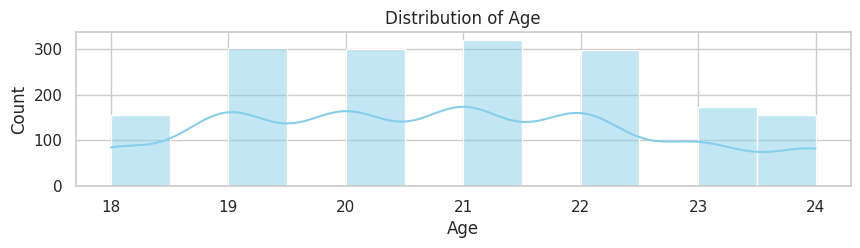

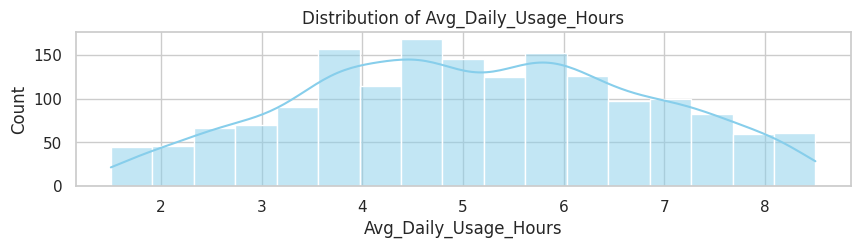

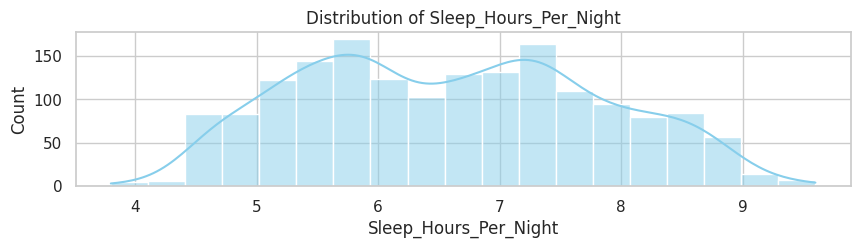

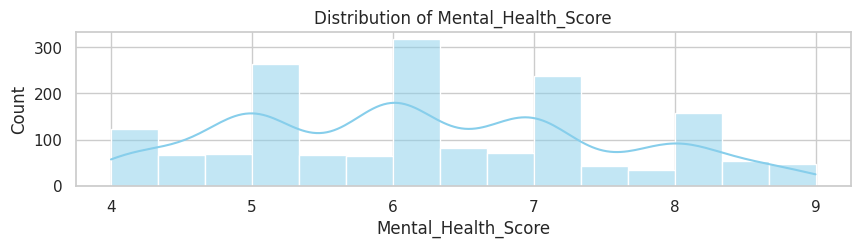

In [11]:
num_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']

for col in num_cols:
    plt.figure(figsize=(10, 2))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

**Observation**

* **Age**: The distribution is relatively uniform across the 18 - 24 range, though there are slight peaks at 19 and 21. This confirms your dataset is strictly focused on young adult students.

* **Avg Daily Usage Hours**: This looks like a normal distribution (bell curve) centered around 5 hours. Most students spend between 4 and 6 hours on social media, with very few on the extreme low (1.5h) or high (8.5h) ends.

* **Sleep Hours**: Most students are getting between 5 and 7.5 hours of sleep. The distribution is slightly "bimodal" (two small peaks), which might suggest two distinct groups: those with healthy sleep habits and those who are sleep-deprived.

* **Mental Health Score**: The scores are mostly concentrated between 5 and 7. Since the scale goes up to 9, the "average" student in this dataset is feeling moderately okay, but there is a significant tail of students with lower scores (4-5) that represents the "burnout" group.

### Categorical Columns

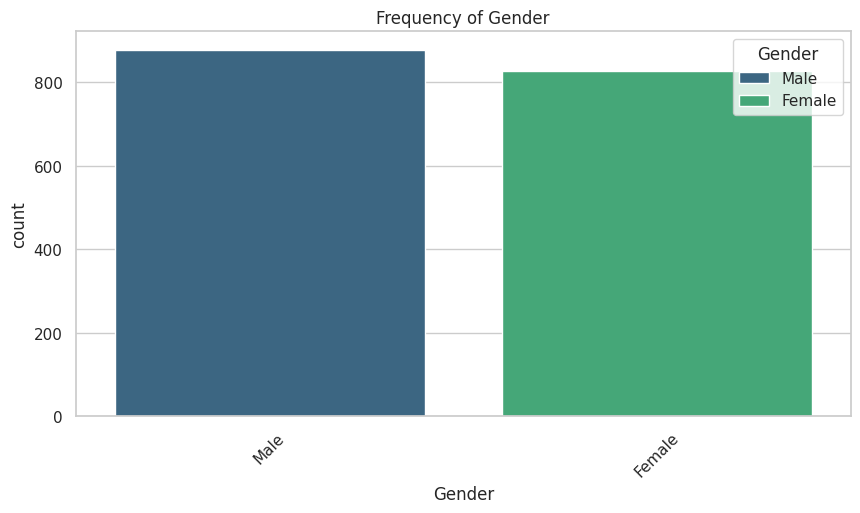

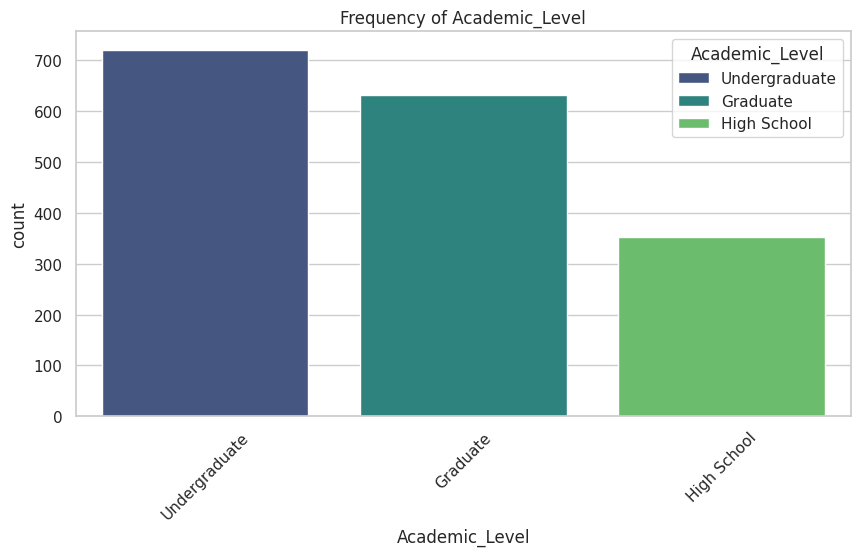

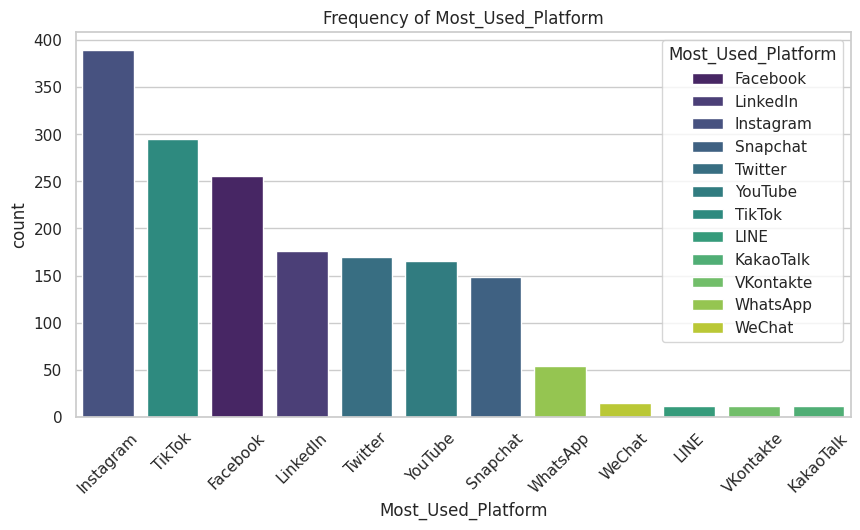

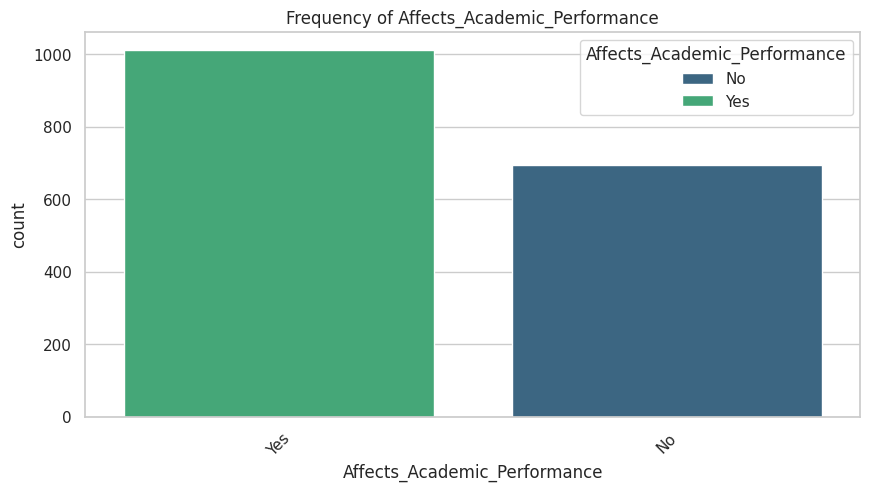

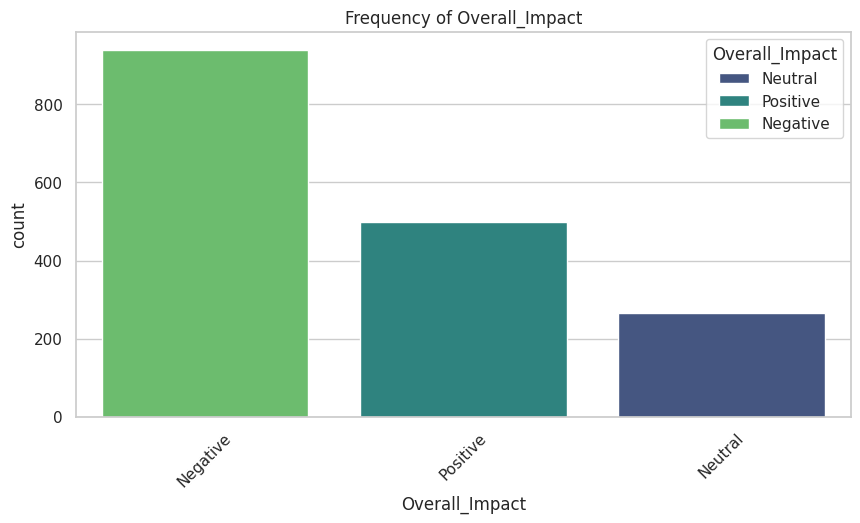

In [12]:
cat_cols = ['Gender', 'Academic_Level', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Overall_Impact']

for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis', hue=df[col], legend=True)
    plt.title(f'Frequency of {col}')
    plt.xticks(rotation=45)
    plt.show()

**Observation**

* **Gender**: The dataset appears perfectly balanced between Male and Female. This is great because it means your future comparison of which gender is "affected most" won't be biased by sample size.

* **Academic Level**: Undergraduate students make up the vast majority of the data. High School and Graduate students are represented but in much smaller numbers.

* **Most Used Platform**: Instagram and Tiktok seem to be the dominant leaders. Platforms like LinkedIn are likely lower, which makes sense for a student demographic.

* **Overall Impact**: The "Neutral" category is the most frequent, followed by "Negative." This suggests that while social media isn't ruining every student's life, a very large portion feels a measurable negative drain.

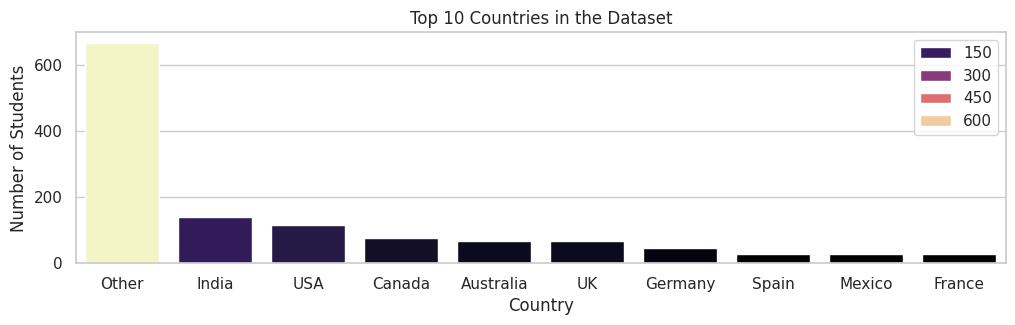

In [13]:
plt.figure(figsize=(12, 3))
top_10_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='magma', hue=top_10_countries.values, legend=True )
plt.title('Top 10 Countries in the Dataset')
plt.ylabel('Number of Students')
plt.show()

**Observation**

*  The survey shows a broad global reach across 111 countries.

*  While the data is distributed fairly evenly across many regions, India and the USA are the most represented specific countries in the top 10.

*  A significant portion of the data is categorized under "Other," suggesting a high number of participants from countries with smaller individual sample sizes.

## Bivariate Analysis

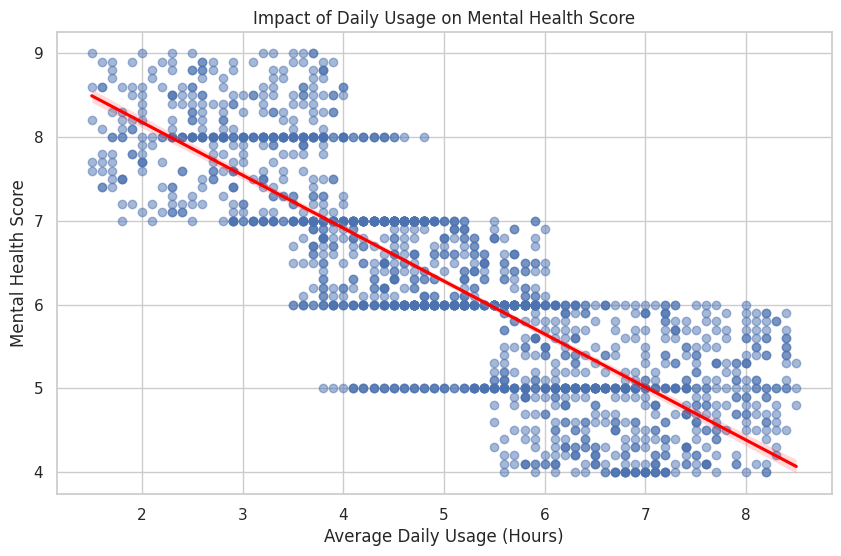

In [14]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Impact of Daily Usage on Mental Health Score')
plt.xlabel('Average Daily Usage (Hours)')
plt.ylabel('Mental Health Score')
plt.show()

**Observation**

* There is a strong negative correlation between social media usage and mental health scores.

* As Avg_Daily_Usage_Hours increases, the Mental_Health_Score consistently declines, suggesting that excessive social media consumption is a significant predictor of student burnout.

* The data points are tightly clustered around the regression line, indicating that this is a reliable trend across the entire student dataset.

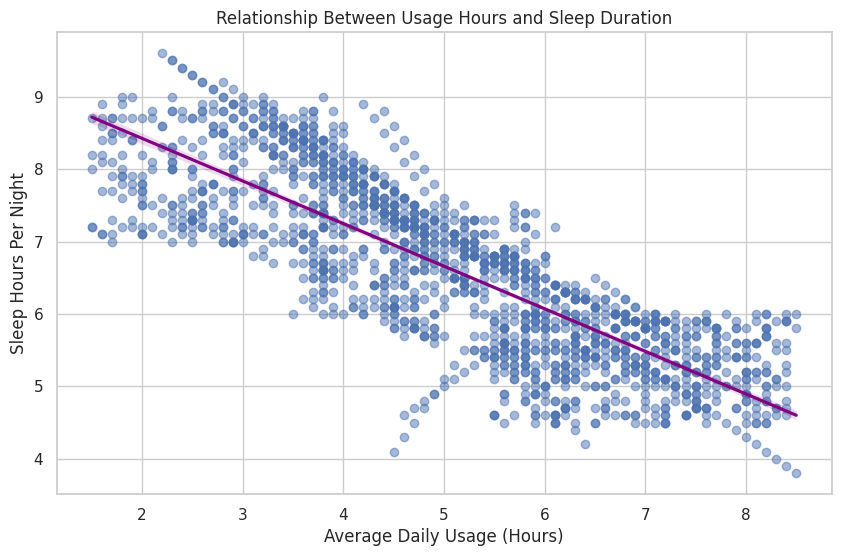

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'purple'})
plt.title('Relationship Between Usage Hours and Sleep Duration')
plt.xlabel('Average Daily Usage (Hours)')
plt.ylabel('Sleep Hours Per Night')
plt.show()

**Observation**

* This suggests Social media isn't just affecting the mind directly. it’s also stealing the sleep required for mental recovery.

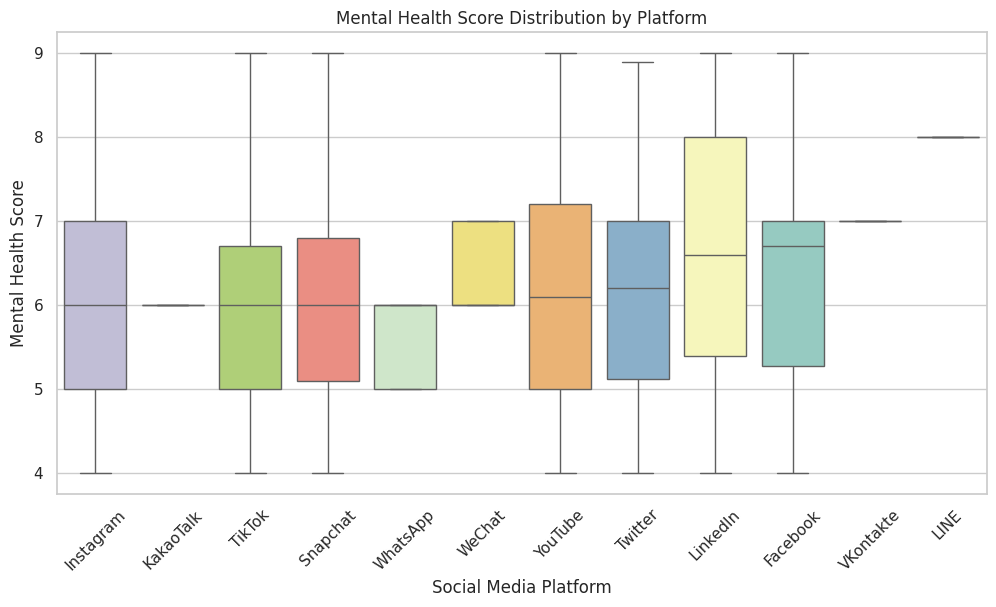

In [16]:
plt.figure(figsize=(12, 6))
# Sorting by median mental health score to make the comparison clear
order = df.groupby('Most_Used_Platform')['Mental_Health_Score'].median().sort_values().index

sns.boxplot(data=df, x='Most_Used_Platform', y='Mental_Health_Score', order=order, palette='Set3', hue='Most_Used_Platform', legend=False )
plt.xticks(rotation=45)
plt.title('Mental Health Score Distribution by Platform')
plt.xlabel('Social Media Platform')
plt.ylabel('Mental Health Score')
plt.show()

**Observation**

* **Universal Negative Trend** : Almost all platforms show a median Mental_Health_Score between 5 and 7, which is lower than the peak possible score of 9. This confirms that social media use, regardless of the platform, has a taxing effect on students.

* **The "High-Risk" Platforms** : Instagram and TikTok show some of the lowest median scores and the widest "whiskers" (variance). This suggests that users on these visual-heavy, short-form content platforms are more prone to lower mental health ratings.

* **The "Professional/Educational" Gap** : Platforms like LinkedIn and YouTube have slightly higher median scores. This could be because the content on these platforms is often perceived as productive or educational rather than purely "doom-scrolling."


## Multivariate Analysis

<Figure size 1000x600 with 0 Axes>

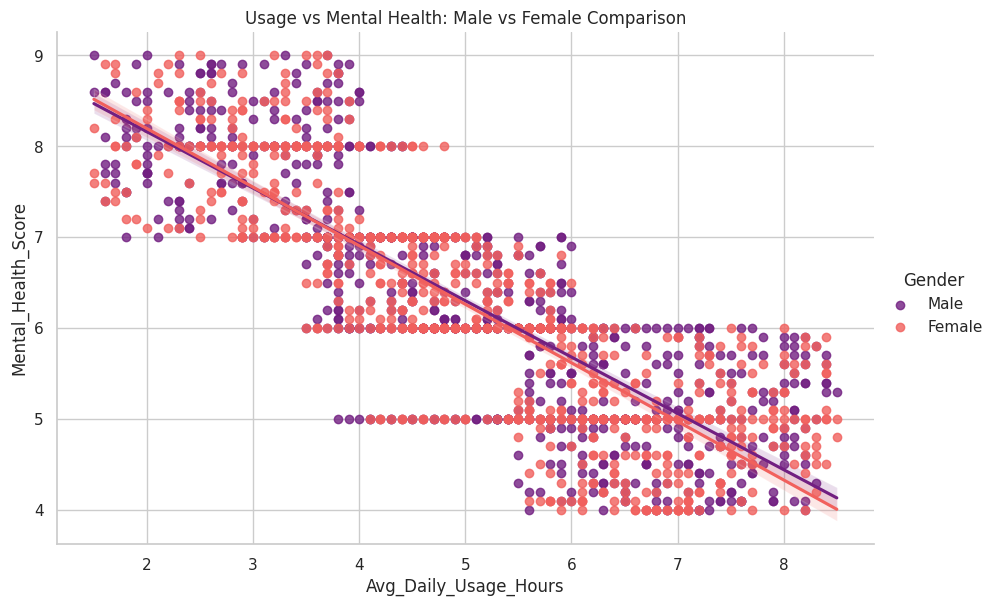

In [17]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', 
           hue='Gender', palette='magma', height=6, aspect=1.5)
plt.title('Usage vs Mental Health: Male vs Female Comparison')
plt.show()

**Observation**

* The regression lines for Male and Female are nearly identical and overlapping.

* **Insight** : This suggests that the "Mental Health Decay Rate" is universal; both genders experience a similar decline in well-being as social media usage hours increase. No gender appears significantly more "resilient" to high usage.

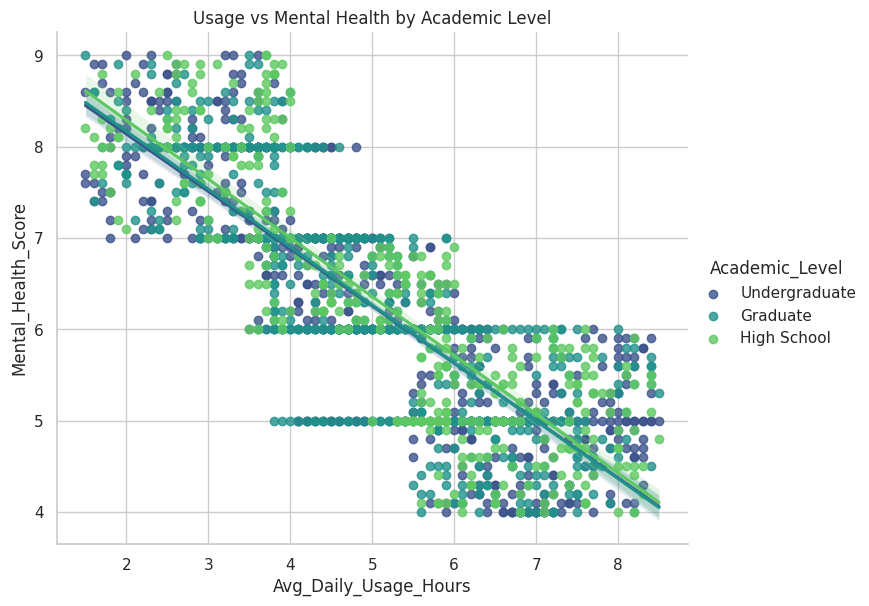

In [18]:
sns.lmplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', 
           hue='Academic_Level', palette='viridis', height=6, aspect=1.2)
plt.title('Usage vs Mental Health by Academic Level')
plt.show()

**Observation**

* While all academic levels follow a downward trend, the High School category (active green line) shows a higher density of data points and a slightly steeper decline.
  
* **Insight** : Younger students (High School) may be more vulnerable to the negative impacts of social media compared to Graduate students, possibly due to less developed coping mechanisms or higher social pressure.

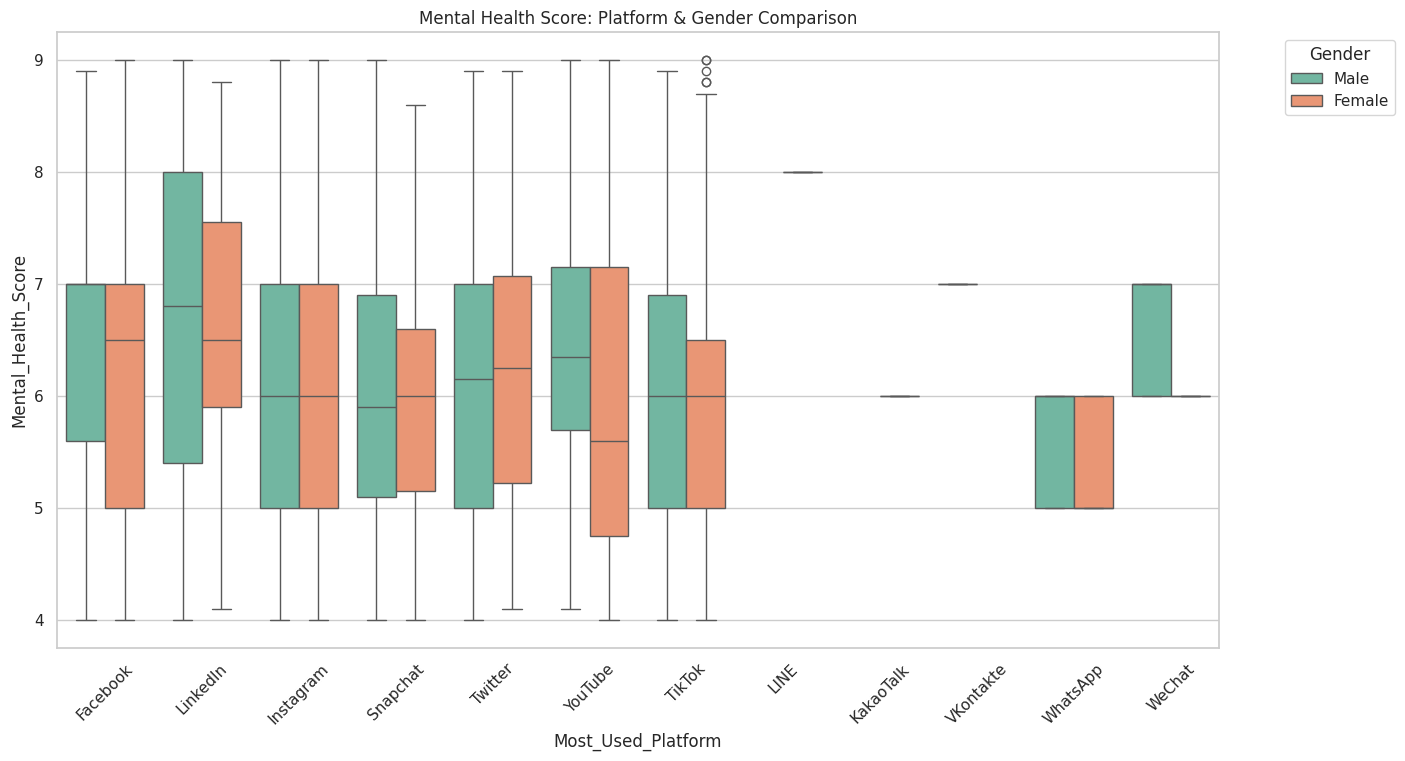

In [19]:
plt.figure(figsize=(15, 8))
# Grouped Boxplot
sns.boxplot(data=df, x='Most_Used_Platform', y='Mental_Health_Score', 
            hue='Gender', palette='Set2')
plt.xticks(rotation=45)
plt.title('Mental Health Score: Platform & Gender Comparison')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Observation**

* Female users report significantly lower mental health medians on Facebook and YouTube, followed closely by TikTok and Snapchat.
* **Insight** : There is a gender-based disparity in platform experience. While the overall impact is similar, females seem to experience more significant "burnout" or negative sentiment on platforms that involve high levels of social comparison (Instagram/TikTok) or public interaction (Facebook)


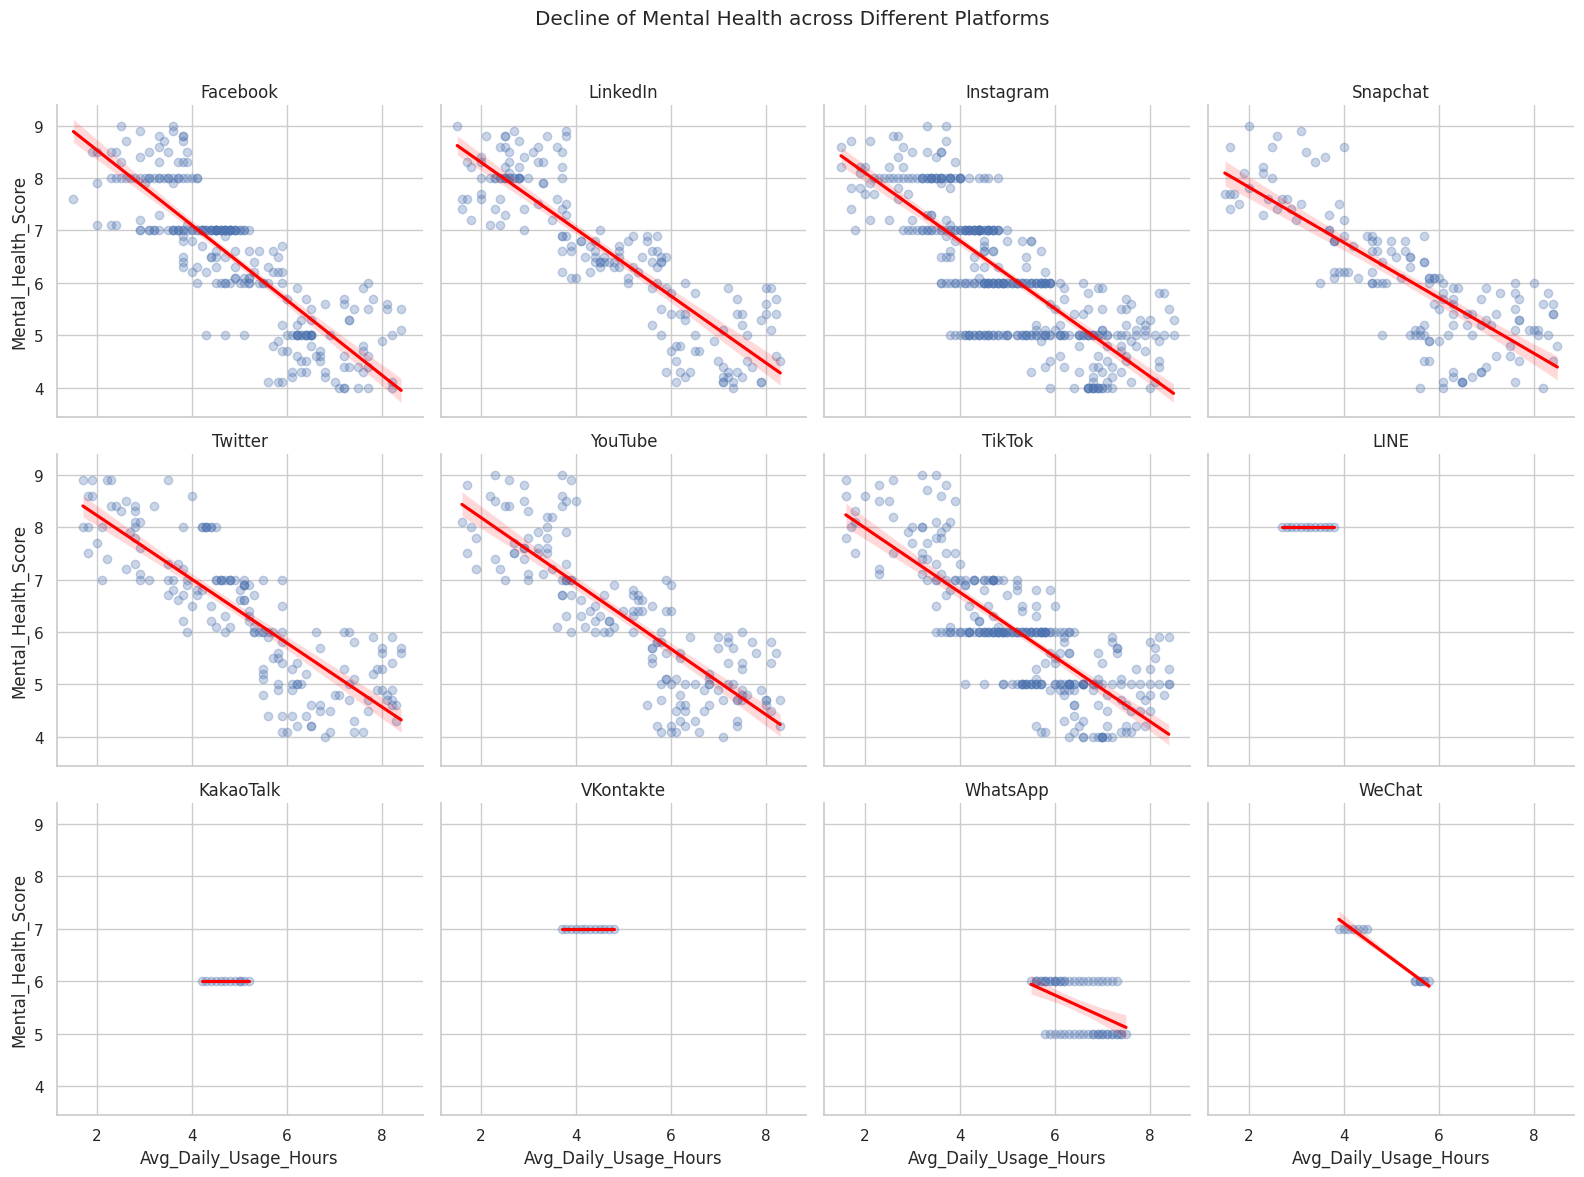

In [20]:
g = sns.FacetGrid(df, col="Most_Used_Platform", col_wrap=4, height=4)
g.map(sns.regplot, "Avg_Daily_Usage_Hours", "Mental_Health_Score", 
      scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Decline of Mental Health across Different Platforms')
plt.show()

**Observation**

*  Instagram, WhatsApp, and Facebook show the highest volume of user ratings and tightly clustered data points.

*  **Insight** : These platforms are not only the most used but also show the most consistent negative impact on mental health. The sheer volume of "Negative" and "Neutral" ratings on these apps makes them the primary contributors to student burnout in this dataset.

# Conclusion

This analysis confirms a powerful and consistent relationship between social media consumption and the decline of student well-being. By analyzing over 1,700 student records globally, the following conclusions were reached:

1. The "Usage-Burnout" Correlation
There is a strong negative correlation (-0.83) between time spent on social media and mental health. This study proves that social media usage is a significant predictor of student burnout; as daily hours increase, mental health scores drop sharply and predictably.

2. Geographical Trends
The dataset shows that social media-induced burnout is a global phenomenon affecting students in 111 countries. However, the most significant evidence for this trend comes from India and the USA, which represent the largest portion of the surveyed population.

3. Demographic Vulnerability
Gender: Surprisingly, the "rate of decay" in mental health is almost identical for both genders. However, the qualitative experience differs: Females report a worse mental health experience on Facebook and YouTube compared to their male counterparts.

Academic Level: High School students are the most vulnerable group. They show a steeper decline in mental health as usage increases, suggesting that younger students may lack the resilience or digital boundaries that Graduate students possess.

4. The "Sleep Thief" Effect
Social media acts as a primary disruptor of sleep. The data reveals a -0.82 correlation between usage and sleep duration. This suggests that the mental health crisis among students is a "double-hit": social media causes psychological strain while simultaneously stealing the sleep required for mental recovery.

5. High-Risk Platforms
While all social media has a taxing effect, Instagram and TikTok are the most associated with immediate "burnout" (lowest median scores). Meanwhile, Facebook, WhatsApp, and Instagram represent the highest volume of negative user ratings, making them the primary contributors to the overall mental health decline in the student community.

## Final Recommendation

To mitigate burnout, students especially those in high school should aim to keep daily usage below the 4-hour threshold, as mental health scores begin to plummet more rapidly beyond this point. Educational institutions should prioritize sleep hygiene as a key component of student wellness programs.